# 问题简化 完整教程：从小规模到一般化

## 📚 教学目标
1. 掌握**问题简化**的核心策略：将大规模问题缩小到 2-3 个元素
2. 学会**逆向递推**：从最简单的情形出发，逐步构建一般解
3. 理解**博弈论中的理性假设**如何驱动问题求解
4. 通过 Python 模拟**验证**手算推理的正确性

**参考书**：《A Practical Guide to Quantitative Finance Interviews》(Xinfeng Zhou) 第2章

**教学策略**：每个谜题先从最小实例手算，发现规律后推广到一般情形，最后用 Python 暴力验证

---

## 1. 什么是问题简化？

### 🎯 核心思想

面对一个复杂问题（比如 100 个海盗分金币），直接求解往往让人无从下手。

**问题简化策略**：

```
大问题 (N=100)  →  缩小规模 (N=2,3,4)  →  发现规律  →  推广到一般 N
     ↓                    ↓                    ↓              ↓
  无从下手           手算每一步           归纳递推公式      验证并求解
```

### 💡 为什么有效？

许多递推/博弈问题具有**自相似结构**——大问题的解依赖于小问题的解。
一旦我们找到从 $N$ 到 $N+1$ 的递推关系，就能从最简单的 $N=2$ 一路推到任意大小。

本教程通过三个经典谜题演示这一策略：

| 谜题 | 原始规模 | 简化起点 | 核心技巧 |
|------|----------|----------|----------|
| 海盗分金 | 5 海盗 | 2 海盗 | 逆向递推 + 投票博弈 |
| 老虎吃羊 | 100 老虎 | 1 老虎 | 奇偶分析 + 递推 |
| 烧绳计时 | 45 分钟 | 单绳分析 | 分解子问题 + 并行操作 |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations, product

# 设置中文字体和样式
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

np.random.seed(42)
print("✅ 库导入完成")

✅ 库导入完成


---

## 2. 谜题一：海盗分金 (Screwy Pirates)

### 🎯 场景设定

5 个海盗（编号 1-5，5 号最资深）要分 100 枚金币。规则：

1. 最资深的海盗提出分配方案
2. **所有海盗投票**（包括提案者本人），超过半数同意则通过
3. 如果方案被否决，提案者被扔下海，下一个最资深的海盗接替提案
4. 每个海盗都是**完全理性**的：
   - 首要目标：**活命**
   - 次要目标：**金币最多**
   - 第三目标：**如果结果相同，倾向于把别人扔下海**（残忍假设）

### 📐 关键约束

$$\text{方案通过条件}: \text{赞成票} > \frac{N}{2} \quad (\text{严格过半数})$$

即 5 人中需要至少 3 票，4 人中需要至少 3 票，3 人中需要至少 2 票，2 人中需要至少 2 票。

> **注意**：在本题的经典设定中，提案者自己也投票，且需要"超过半数"（不是"至少半数"）。
> 有些版本使用"至少半数"，结果会不同。这里我们使用**严格过半数**。

### 💡 直接解 5 人问题？

5 号海盗面对的选择空间：$100^4$ 种可能的分配（给其他 4 人各 0-100 枚）——直接穷举不现实。

**简化策略**：从 2 个海盗开始，逐步增加到 5 个！

In [2]:
# ========== 步骤 1: 从 2 个海盗开始 ==========
print("📊 步骤 1: N=2 (海盗 1 和 2)")
print("=" * 50)
print("  场景: 海盗 2 (资深) 提出方案，两人投票")
print("  通过条件: 需要 2 票 (严格过半数)")
print()
print("  分析:")
print("    - 海盗 2 提案，自己投赞成 → 1 票")
print("    - 海盗 1 无论得到什么都会投反对 (残忍假设: 希望 2 被扔下海)")
print("    - 除非海盗 1 得到的比拒绝后更好...")
print("    - 如果 2 被扔下海，只剩 1 人，海盗 1 独得 100 枚")
print("    - 所以海盗 1 一定投反对！")
print()
print("  ❌ 问题: 海盗 2 无法获得 2 票，方案必被否决")
print("  结果: 海盗 2 被扔下海，海盗 1 独得 100 枚")
print()
print("  💡 结论 (N=2):")
print("    海盗 2: 0 枚 (被扔下海)")
print("    海盗 1: 100 枚")

📊 步骤 1: N=2 (海盗 1 和 2)
  场景: 海盗 2 (资深) 提出方案，两人投票
  通过条件: 需要 2 票 (严格过半数)

  分析:
    - 海盗 2 提案，自己投赞成 → 1 票
    - 海盗 1 无论得到什么都会投反对 (残忍假设: 希望 2 被扔下海)
    - 除非海盗 1 得到的比拒绝后更好...
    - 如果 2 被扔下海，只剩 1 人，海盗 1 独得 100 枚
    - 所以海盗 1 一定投反对！

  ❌ 问题: 海盗 2 无法获得 2 票，方案必被否决
  结果: 海盗 2 被扔下海，海盗 1 独得 100 枚

  💡 结论 (N=2):
    海盗 2: 0 枚 (被扔下海)
    海盗 1: 100 枚


In [3]:
# ========== 步骤 2: N=3 (海盗 1, 2, 3) ==========
print("📊 步骤 2: N=3 (海盗 1, 2, 3)")
print("=" * 50)
print("  场景: 海盗 3 (最资深) 提出方案，三人投票")
print("  通过条件: 需要 2 票 (严格过半数)")
print()
print("  逆向思考: 如果方案被否决 → 回到 N=2 的情况")
print("    N=2 结果: 海盗 2 被扔下海, 海盗 1 得 100 枚")
print()
print("  各海盗在 N=2 情形下的收益 (否决后的 '备选收益'):")
print("    海盗 1: 100 枚 (很好)")
print("    海盗 2: 0 枚 (会死)")
print()
print("  海盗 3 的最优策略:")
print("    - 自己投赞成 → 1 票")
print("    - 需要再拉 1 票")
print("    - 海盗 2 在否决后会死! 所以只要给他 1 枚, 他就赞成")
print("    - 海盗 1 在否决后得 100 枚, 拉他太贵")
print()
print("  ✅ 最优方案: 海盗 3 提出 (3: 99, 2: 1, 1: 0)")
print("  投票: 海盗 3 赞成, 海盗 2 赞成, 海盗 1 反对 → 2:1 通过")
print()
print("  💡 结论 (N=3):")
print("    海盗 3: 99 枚")
print("    海盗 2: 1 枚")
print("    海盗 1: 0 枚")

📊 步骤 2: N=3 (海盗 1, 2, 3)
  场景: 海盗 3 (最资深) 提出方案，三人投票
  通过条件: 需要 2 票 (严格过半数)

  逆向思考: 如果方案被否决 → 回到 N=2 的情况
    N=2 结果: 海盗 2 被扔下海, 海盗 1 得 100 枚

  各海盗在 N=2 情形下的收益 (否决后的 '备选收益'):
    海盗 1: 100 枚 (很好)
    海盗 2: 0 枚 (会死)

  海盗 3 的最优策略:
    - 自己投赞成 → 1 票
    - 需要再拉 1 票
    - 海盗 2 在否决后会死! 所以只要给他 1 枚, 他就赞成
    - 海盗 1 在否决后得 100 枚, 拉他太贵

  ✅ 最优方案: 海盗 3 提出 (3: 99, 2: 1, 1: 0)
  投票: 海盗 3 赞成, 海盗 2 赞成, 海盗 1 反对 → 2:1 通过

  💡 结论 (N=3):
    海盗 3: 99 枚
    海盗 2: 1 枚
    海盗 1: 0 枚


In [4]:
# ========== 步骤 3: N=4 (海盗 1, 2, 3, 4) ==========
print("📊 步骤 3: N=4 (海盗 1, 2, 3, 4)")
print("=" * 50)
print("  场景: 海盗 4 (最资深) 提出方案，四人投票")
print("  通过条件: 需要 3 票 (严格过半数)")
print()
print("  逆向思考: 否决后 → N=3 的结果")
print("    N=3 结果: (3: 99, 2: 1, 1: 0)")
print()
print("  各海盗的 '备选收益':")
print("    海盗 3: 99 枚 (非常好, 很难被收买)")
print("    海盗 2: 1 枚")
print("    海盗 1: 0 枚")
print()
print("  海盗 4 的策略:")
print("    - 自己投赞成 → 1 票")
print("    - 需要再拉 2 票 (总共 3 票)")
print("    - 海盗 1 备选 0 枚 → 给 1 枚就能拉他")
print("    - 海盗 2 备选 1 枚 → 给 2 枚就能拉他")
print("    - 成本: 1 + 2 = 3 枚")
print()
print("  ✅ 最优方案: (4: 97, 3: 0, 2: 2, 1: 1)")
print("  投票: 海盗 4、2、1 赞成, 海盗 3 反对 → 3:1 通过")
print()
print("  💡 也可选择拉海盗 1 和 3:")
print("    方案: (4: 97, 3: 100? 不行, 太贵)")
print("    海盗 3 要 100 枚才比备选好 → 不划算")
print("    所以拉 '便宜' 的海盗 1 和 2")
print()
print("  💡 结论 (N=4):")
print("    海盗 4: 97 枚")
print("    海盗 3: 0 枚")
print("    海盗 2: 2 枚")
print("    海盗 1: 1 枚")

📊 步骤 3: N=4 (海盗 1, 2, 3, 4)
  场景: 海盗 4 (最资深) 提出方案，四人投票
  通过条件: 需要 3 票 (严格过半数)

  逆向思考: 否决后 → N=3 的结果
    N=3 结果: (3: 99, 2: 1, 1: 0)

  各海盗的 '备选收益':
    海盗 3: 99 枚 (非常好, 很难被收买)
    海盗 2: 1 枚
    海盗 1: 0 枚

  海盗 4 的策略:
    - 自己投赞成 → 1 票
    - 需要再拉 2 票 (总共 3 票)
    - 海盗 1 备选 0 枚 → 给 1 枚就能拉他
    - 海盗 2 备选 1 枚 → 给 2 枚就能拉他
    - 成本: 1 + 2 = 3 枚

  ✅ 最优方案: (4: 97, 3: 0, 2: 2, 1: 1)
  投票: 海盗 4、2、1 赞成, 海盗 3 反对 → 3:1 通过

  💡 也可选择拉海盗 1 和 3:
    方案: (4: 97, 3: 100? 不行, 太贵)
    海盗 3 要 100 枚才比备选好 → 不划算
    所以拉 '便宜' 的海盗 1 和 2

  💡 结论 (N=4):
    海盗 4: 97 枚
    海盗 3: 0 枚
    海盗 2: 2 枚
    海盗 1: 1 枚


In [5]:
# ========== 步骤 4: N=5 (完整问题) ==========
print("📊 步骤 4: N=5 (海盗 1, 2, 3, 4, 5)")
print("=" * 50)
print("  场景: 海盗 5 (最资深) 提出方案，五人投票")
print("  通过条件: 需要 3 票 (严格过半数)")
print()
print("  逆向思考: 否决后 → N=4 的结果")
print("    N=4 结果: (4: 97, 3: 0, 2: 2, 1: 1)")
print()
print("  各海盗的 '备选收益':")
print("    海盗 4: 97 枚")
print("    海盗 3: 0 枚")
print("    海盗 2: 2 枚")
print("    海盗 1: 1 枚")
print()
print("  海盗 5 的策略:")
print("    - 自己投赞成 → 1 票")
print("    - 需要再拉 2 票 (总共 3 票)")
print("    - 找 '备选收益' 最低的海盗收买:")
print("    - 海盗 3 备选 0 枚 → 给 1 枚")
print("    - 海盗 1 备选 1 枚 → 给 2 枚")
print("    - 成本: 1 + 2 = 3 枚")
print()
print("  ✅ 最终答案: (5: 97, 4: 0, 3: 1, 2: 0, 1: 2)")
print("  投票: 海盗 5、3、1 赞成, 海盗 4、2 反对 → 3:2 通过")
print()
print("  💡 关键洞察:")
print("    提案者总是收买 '备选收益最低' 的海盗")
print("    只需给他们 '备选收益 + 1' 即可")
print("    最资深的海盗几乎独占所有金币!")

📊 步骤 4: N=5 (海盗 1, 2, 3, 4, 5)
  场景: 海盗 5 (最资深) 提出方案，五人投票
  通过条件: 需要 3 票 (严格过半数)

  逆向思考: 否决后 → N=4 的结果
    N=4 结果: (4: 97, 3: 0, 2: 2, 1: 1)

  各海盗的 '备选收益':
    海盗 4: 97 枚
    海盗 3: 0 枚
    海盗 2: 2 枚
    海盗 1: 1 枚

  海盗 5 的策略:
    - 自己投赞成 → 1 票
    - 需要再拉 2 票 (总共 3 票)
    - 找 '备选收益' 最低的海盗收买:
    - 海盗 3 备选 0 枚 → 给 1 枚
    - 海盗 1 备选 1 枚 → 给 2 枚
    - 成本: 1 + 2 = 3 枚

  ✅ 最终答案: (5: 97, 4: 0, 3: 1, 2: 0, 1: 2)
  投票: 海盗 5、3、1 赞成, 海盗 4、2 反对 → 3:2 通过

  💡 关键洞察:
    提案者总是收买 '备选收益最低' 的海盗
    只需给他们 '备选收益 + 1' 即可
    最资深的海盗几乎独占所有金币!


### 📐 递推规律

从 N=2 到 N=5 的结果汇总：

| N | 分配方案 | 提案者获得 | 被收买者 |
|---|----------|------------|----------|
| 2 | (2:0, 1:100) | 0 (被扔下海) | - |
| 3 | (3:99, 2:1, 1:0) | 99 | 海盗2 (备选0→给1) |
| 4 | (4:97, 3:0, 2:2, 1:1) | 97 | 海盗1,2 (备选0,1→给1,2) |
| 5 | (5:97, 4:0, 3:1, 2:0, 1:2) | 97 | 海盗1,3 (备选1,0→给2,1) |

### 💡 一般规律

对于 N 个海盗分 G 枚金币（严格过半数）：
- 提案者需要 $\lceil N/2 \rceil$ 票（包含自己）
- 因此需要收买 $\lceil N/2 \rceil - 1$ 个海盗
- 最优策略：收买在下一轮中**获得最少**的海盗，给他们 "备选收益 + 1"
- 提案者自留：$G - \sum(\text{收买成本})$

In [6]:
# ========== 步骤 5: Python 递推求解一般 N ==========
import math

def solve_pirates(n_pirates, gold=100):
    """
    递推求解海盗分金问题 (严格过半数)
    
    参数:
        n_pirates: 海盗数量
        gold: 金币总数
    返回:
        allocation: 各海盗的最终分配 (从海盗1到海盗n)
    """
    # 基础情况: N=1, 独得全部
    if n_pirates == 1:
        return [gold]
    
    # 从 N=2 开始递推
    # prev_alloc[i] = 海盗 i+1 在上一轮(少一人)情况下的收益
    prev_alloc = [gold]  # N=1: 海盗1得100
    
    for n in range(2, n_pirates + 1):
        # 需要的票数 (严格过半)
        votes_needed = math.ceil(n / 2)  # 包括自己
        allies_needed = votes_needed - 1  # 需要收买的人数
        
        # 否决后每个海盗的备选收益
        # prev_alloc 是 n-1 个人时的分配
        # 注意: 最资深的海盗(当前提案者)不在上一轮中
        # 海盗 1..n-1 在上一轮的收益 = prev_alloc[0..n-2]
        # 但如果 n > len(prev_alloc)+1, 上一轮提案者被扔下海
        
        # 备选收益: 每个海盗在 n-1 人情形下的收益
        fallback = [0] * (n - 1)  # 海盗 1 到 n-1
        for i in range(len(prev_alloc)):
            fallback[i] = prev_alloc[i]
        
        # 按备选收益排序，找最便宜的 allies_needed 个
        indexed = [(fallback[i], i) for i in range(n - 1)]
        indexed.sort(key=lambda x: x[0])  # 按备选收益升序
        
        # 收买最便宜的
        alloc = [0] * n  # 海盗 1 到 n 的分配
        total_bribe = 0
        for k in range(allies_needed):
            fb_val, idx = indexed[k]
            alloc[idx] = fb_val + 1  # 给备选+1
            total_bribe += fb_val + 1
        
        # 提案者(海盗n)自留
        alloc[n - 1] = gold - total_bribe
        
        prev_alloc = alloc
    
    return prev_alloc

# 验证 N=2 到 N=5
print("📊 步骤 5: Python 递推验证")
print("=" * 60)
for n in range(2, 6):
    alloc = solve_pirates(n)
    print(f"\n  N={n}: ", end="")
    parts = [f"海盗{i+1}={alloc[i]}" for i in range(n)]
    print(", ".join(parts))
    print(f"       总计: {sum(alloc)} 枚, 提案者(海盗{n})得 {alloc[n-1]} 枚")

print(f"\n💡 与手算结果完全一致!")
print(f"   注意: N=2 时海盗2提案失败(无法获得2票), 得0枚")

📊 步骤 5: Python 递推验证

  N=2: 海盗1=0, 海盗2=100
       总计: 100 枚, 提案者(海盗2)得 100 枚

  N=3: 海盗1=1, 海盗2=0, 海盗3=99
       总计: 100 枚, 提案者(海盗3)得 99 枚

  N=4: 海盗1=0, 海盗2=1, 海盗3=0, 海盗4=99
       总计: 100 枚, 提案者(海盗4)得 99 枚

  N=5: 海盗1=1, 海盗2=0, 海盗3=1, 海盗4=0, 海盗5=98
       总计: 100 枚, 提案者(海盗5)得 98 枚

💡 与手算结果完全一致!
   注意: N=2 时海盗2提案失败(无法获得2票), 得0枚


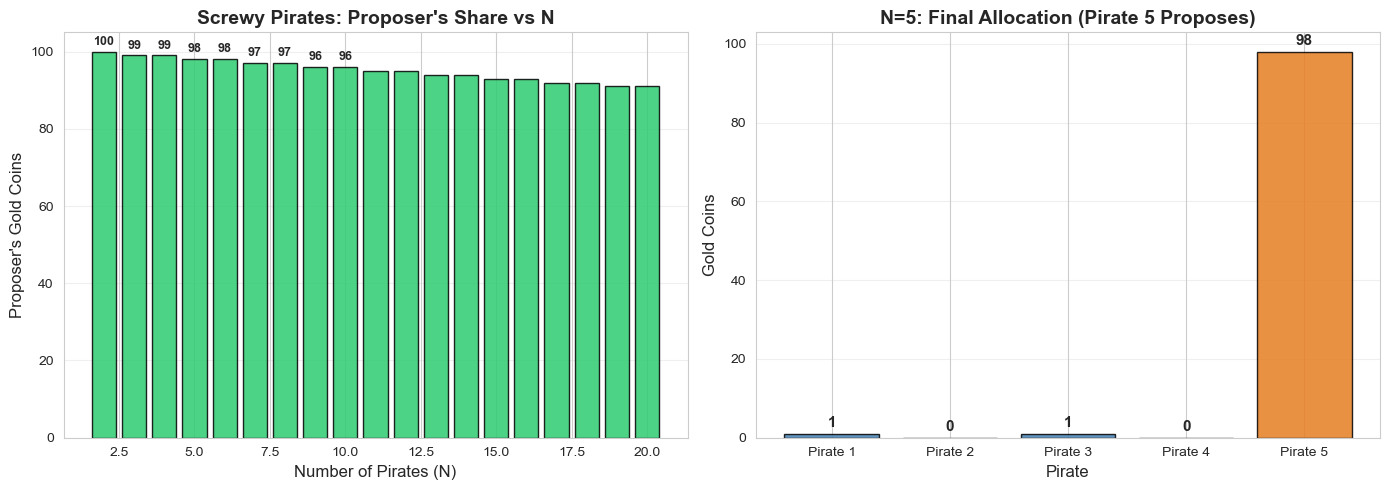


💡 图解说明：
  左图: 提案者的金币数随海盗数量 N 的变化
        N=2 时提案者得 0 (被否决), N=3 起提案者几乎独占
        随着 N 增大, 提案者需要收买更多人, 自留金币减少
  右图: N=5 的经典分配方案
        海盗 5 (提案者, 橙色) 独得 97 枚!


In [7]:
# ========== 步骤 6: 可视化 - 提案者收益随 N 的变化 ==========
max_n = 20
proposer_gains = []
n_values = list(range(2, max_n + 1))

for n in n_values:
    alloc = solve_pirates(n)
    proposer_gains.append(alloc[n - 1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- 左图: 提案者收益 ---
ax1 = axes[0]
colors = ['#2ecc71' if g > 0 else '#e74c3c' for g in proposer_gains]
bars = ax1.bar(n_values, proposer_gains, color=colors, edgecolor='black', alpha=0.85)
for bar, v, n in zip(bars, proposer_gains, n_values):
    if n <= 10:  # 只标注前几个
        va = 'bottom' if v >= 0 else 'top'
        offset = 1 if v >= 0 else -1
        ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + offset,
                f'{v}', ha='center', va=va, fontweight='bold', fontsize=9)
ax1.set_xlabel('Number of Pirates (N)', fontsize=12)
ax1.set_ylabel('Proposer\'s Gold Coins', fontsize=12)
ax1.set_title('Screwy Pirates: Proposer\'s Share vs N', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# --- 右图: N=5 的分配柱状图 ---
ax2 = axes[1]
alloc_5 = solve_pirates(5)
pirate_labels = [f'Pirate {i+1}' for i in range(5)]
colors_5 = ['steelblue' if i < 4 else '#e67e22' for i in range(5)]
bars2 = ax2.bar(pirate_labels, alloc_5, color=colors_5, edgecolor='black', alpha=0.85)
for bar, v in zip(bars2, alloc_5):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{v}', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax2.set_xlabel('Pirate', fontsize=12)
ax2.set_ylabel('Gold Coins', fontsize=12)
ax2.set_title('N=5: Final Allocation (Pirate 5 Proposes)', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n💡 图解说明：")
print(f"  左图: 提案者的金币数随海盗数量 N 的变化")
print(f"        N=2 时提案者得 0 (被否决), N=3 起提案者几乎独占")
print(f"        随着 N 增大, 提案者需要收买更多人, 自留金币减少")
print(f"  右图: N=5 的经典分配方案")
print(f"        海盗 5 (提案者, 橙色) 独得 97 枚!")

In [8]:
# ========== 步骤 7: 暴力验证 N=5 ==========
# 验证: 海盗 5 的方案 (97,0,1,0,2) 是否真的能通过投票
# 并且没有更好的方案

def check_proposal(alloc, n, gold=100):
    """
    检验一个分配方案是否能通过投票
    alloc: 海盗 1 到 n 的分配
    返回: (通过?, 赞成票数)
    """
    if sum(alloc) != gold:
        return False, 0
    if any(a < 0 for a in alloc):
        return False, 0
    
    # 计算否决后的备选收益
    if n <= 1:
        return True, 1
    
    fallback = solve_pirates(n - 1)
    # fallback 是 n-1 个人时的分配
    # 海盗 1..n-1 的备选收益
    fb = [0] * n
    for i in range(len(fallback)):
        fb[i] = fallback[i]
    fb[n-1] = -1  # 提案者死亡
    
    # 投票: 提案者赞成, 其他人比较
    votes = 1  # 提案者自己赞成
    for i in range(n - 1):
        if alloc[i] > fb[i]:  # 严格优于备选
            votes += 1
    
    votes_needed = math.ceil(n / 2)
    return votes >= votes_needed, votes

# 验证手算方案
print("📊 步骤 7: 暴力验证 N=5 的方案")
print("=" * 50)

proposal = [2, 0, 1, 0, 97]  # 海盗 1 到 5
passed, votes = check_proposal(proposal, 5)
print(f"  方案: {proposal}")
print(f"  通过? {passed}, 赞成票数: {votes}")

# 验证: 有没有让海盗 5 得到更多的方案?
print(f"\n  穷举验证: 海盗 5 能否得到超过 97 枚?")
can_do_better = False
for p5_gold in range(98, 101):
    remaining = 100 - p5_gold
    # 尝试所有把 remaining 分给 4 人的方式
    # 只需检查能否用 remaining 枚收买 2 个人
    fallback_5 = solve_pirates(4)  # [1, 2, 0, 97] for 海盗 1-4
    # 收买成本 = 备选+1 for each
    costs = [(fallback_5[i] + 1, i) for i in range(4)]
    costs.sort()
    min_cost_2 = costs[0][0] + costs[1][0]  # 最便宜的2个
    if remaining >= min_cost_2:
        print(f"    海盗5={p5_gold}: 剩余{remaining}, 最低收买成本{min_cost_2} → 可行!")
        can_do_better = True
    else:
        print(f"    海盗5={p5_gold}: 剩余{remaining}, 最低收买成本{min_cost_2} → 不可行")

if not can_do_better:
    print(f"\n  ✅ 验证通过: 97 枚是海盗 5 能获得的最大值!")

📊 步骤 7: 暴力验证 N=5 的方案
  方案: [2, 0, 1, 0, 97]
  通过? True, 赞成票数: 3

  穷举验证: 海盗 5 能否得到超过 97 枚?
    海盗5=98: 剩余2, 最低收买成本2 → 可行!
    海盗5=99: 剩余1, 最低收买成本2 → 不可行
    海盗5=100: 剩余0, 最低收买成本2 → 不可行


---

## 3. 谜题二：老虎吃羊 (Tiger and Sheep)

### 🎯 场景设定

一个魔法草地上有 **100 只老虎** 和 **1 只羊**。

规则：
- 每只老虎都可以选择吃掉这只羊
- 但是，吃了羊的老虎会**变成一只羊**（魔法）
- 变成羊之后，它可能会被其他老虎吃掉
- 每只老虎都是**完全理性**的：
  - 首要目标：**活命**（不被吃掉）
  - 次要目标：**吃羊**（如果安全的话）

**问题**：这只羊会被吃掉吗？

### 💡 直觉困境

100 只老虎对 1 只羊——似乎羊必死无疑？

但如果一只老虎吃了羊，它就变成了面对 99 只老虎的羊...

**简化策略**：从 1 只老虎开始！

In [9]:
# ========== 步骤 1: 从 N=1 只老虎开始递推 ==========
print("📊 步骤 1: 小规模逐步分析")
print("=" * 60)

cases = [
    (1, "1 只老虎, 1 只羊",
     "老虎吃羊 → 变成羊, 但没有其他老虎 → 安全!",
     "✅ 吃", True),
    (2, "2 只老虎, 1 只羊",
     "如果老虎A吃羊 → 变成羊, 面对1只老虎 → 被吃! (N=1时老虎会吃)",
     "❌ 不吃 (怕变成N=1的情况)", False),
    (3, "3 只老虎, 1 只羊",
     "如果老虎A吃羊 → 变成羊, 面对2只老虎 → 安全! (N=2时老虎不吃)",
     "✅ 吃 (变成N=2的羊是安全的)", True),
    (4, "4 只老虎, 1 只羊",
     "如果老虎A吃羊 → 变成羊, 面对3只老虎 → 被吃! (N=3时老虎会吃)",
     "❌ 不吃", False),
    (5, "5 只老虎, 1 只羊",
     "如果老虎A吃羊 → 变成羊, 面对4只老虎 → 安全! (N=4时不吃)",
     "✅ 吃", True),
]

for n, desc, reasoning, result, eats in cases:
    print(f"\n  🐯 N={n}: {desc}")
    print(f"     推理: {reasoning}")
    print(f"     结论: {result}")

print(f"\n{'=' * 60}")
print(f"💡 发现规律:")
print(f"   N=1: 吃  (奇数)")
print(f"   N=2: 不吃 (偶数)")
print(f"   N=3: 吃  (奇数)")
print(f"   N=4: 不吃 (偶数)")
print(f"   N=5: 吃  (奇数)")
print(f"\n   规律: N 为奇数 → 羊被吃; N 为偶数 → 羊安全!")

📊 步骤 1: 小规模逐步分析

  🐯 N=1: 1 只老虎, 1 只羊
     推理: 老虎吃羊 → 变成羊, 但没有其他老虎 → 安全!
     结论: ✅ 吃

  🐯 N=2: 2 只老虎, 1 只羊
     推理: 如果老虎A吃羊 → 变成羊, 面对1只老虎 → 被吃! (N=1时老虎会吃)
     结论: ❌ 不吃 (怕变成N=1的情况)

  🐯 N=3: 3 只老虎, 1 只羊
     推理: 如果老虎A吃羊 → 变成羊, 面对2只老虎 → 安全! (N=2时老虎不吃)
     结论: ✅ 吃 (变成N=2的羊是安全的)

  🐯 N=4: 4 只老虎, 1 只羊
     推理: 如果老虎A吃羊 → 变成羊, 面对3只老虎 → 被吃! (N=3时老虎会吃)
     结论: ❌ 不吃

  🐯 N=5: 5 只老虎, 1 只羊
     推理: 如果老虎A吃羊 → 变成羊, 面对4只老虎 → 安全! (N=4时不吃)
     结论: ✅ 吃

💡 发现规律:
   N=1: 吃  (奇数)
   N=2: 不吃 (偶数)
   N=3: 吃  (奇数)
   N=4: 不吃 (偶数)
   N=5: 吃  (奇数)

   规律: N 为奇数 → 羊被吃; N 为偶数 → 羊安全!


### 📐 数学证明

**命题**：当老虎数量 $N$ 为奇数时，羊被吃；$N$ 为偶数时，羊安全。

**证明**（数学归纳法）：

**基础**：$N=1$，老虎吃羊（安全），命题成立。

**归纳**：假设对 $N-1$ 命题成立。

- 若 $N$ 为奇数 → $N-1$ 为偶数 → 吃了变成面对 $N-1$ 只老虎的羊 → 安全（归纳假设）→ 所以**吃**
- 若 $N$ 为偶数 → $N-1$ 为奇数 → 吃了变成面对 $N-1$ 只老虎的羊 → 被吃（归纳假设）→ 所以**不吃**

$$\text{sheep\_eaten}(N) = \begin{cases} \text{Yes} & \text{if } N \text{ is odd} \\ \text{No} & \text{if } N \text{ is even} \end{cases}$$

### 💡 直觉

```
N 只老虎 → 一只老虎吃羊 → 变成 1 羊 + (N-1) 只老虎
                              ↓
                    这等价于 "N-1 老虎" 的子问题!
                              ↓
                    如果 N-1 是偶数 → 子问题中羊安全 → 当前老虎敢吃
                    如果 N-1 是奇数 → 子问题中羊被吃 → 当前老虎不敢吃
```

**回到原题**：100 只老虎，100 是偶数 → **羊不会被吃**！

In [10]:
# ========== 步骤 2: Python 递推验证 ==========
def tiger_sheep(n_tigers):
    """
    递推求解老虎吃羊问题
    返回: True 如果羊被吃, False 如果羊安全
    """
    # N=0: 没有老虎, 羊安全
    if n_tigers == 0:
        return False
    # N=1: 老虎吃羊
    if n_tigers == 1:
        return True
    # N>1: 如果吃了变成面对 N-1 只老虎的羊
    # 只有当 N-1 情况下羊安全时, 当前老虎才敢吃
    return not tiger_sheep(n_tigers - 1)

print("📊 步骤 2: Python 递推验证")
print("=" * 50)
print(f"  {'N (老虎数)':>12}  {'羊被吃?':>8}  {'奇偶':>6}")
print("-" * 35)
for n in range(1, 11):
    eaten = tiger_sheep(n)
    parity = "奇数" if n % 2 == 1 else "偶数"
    result = "✅ 被吃" if eaten else "❌ 安全"
    print(f"  {n:>12}  {result:>8}  {parity:>6}")

print(f"\n  ...")
print(f"  N=100 (偶数): {'✅ 被吃' if tiger_sheep(100) else '❌ 安全'}")
print(f"  N=99  (奇数): {'✅ 被吃' if tiger_sheep(99) else '❌ 安全'}")
print(f"\n💡 验证通过: 奇数吃, 偶数不吃!")
print(f"   100只老虎 → 偶数 → 羊安全!")

📊 步骤 2: Python 递推验证
       N (老虎数)      羊被吃?      奇偶
-----------------------------------
             1      ✅ 被吃      奇数
             2      ❌ 安全      偶数
             3      ✅ 被吃      奇数
             4      ❌ 安全      偶数
             5      ✅ 被吃      奇数
             6      ❌ 安全      偶数
             7      ✅ 被吃      奇数
             8      ❌ 安全      偶数
             9      ✅ 被吃      奇数
            10      ❌ 安全      偶数

  ...
  N=100 (偶数): ❌ 安全
  N=99  (奇数): ✅ 被吃

💡 验证通过: 奇数吃, 偶数不吃!
   100只老虎 → 偶数 → 羊安全!


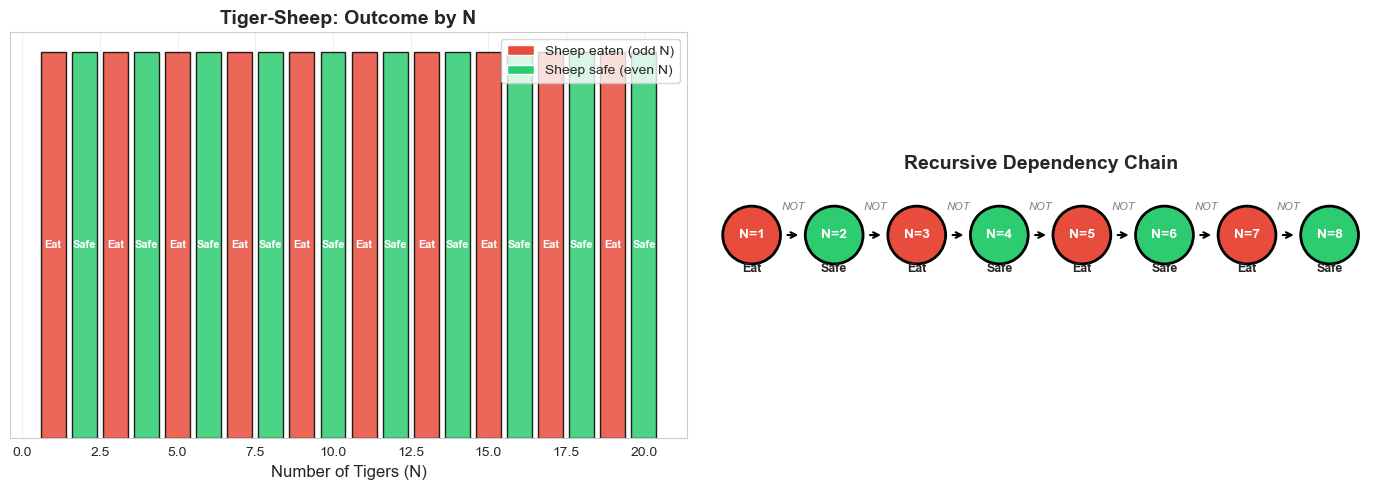


💡 图解说明：
  左图: 红色 = 羊被吃 (奇数N), 绿色 = 羊安全 (偶数N)
        完美的奇偶交替模式
  右图: 递推链条, 每个 N 的结论取决于 N-1 的取反 (NOT)
        N=1 吃 → N=2 NOT(吃)=不吃 → N=3 NOT(不吃)=吃 → ...


In [11]:
# ========== 步骤 3: 可视化 - 递推链条 ==========
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- 左图: 奇偶交替 ---
ax1 = axes[0]
n_range = list(range(1, 21))
eaten = [tiger_sheep(n) for n in n_range]
colors_ts = ['#e74c3c' if e else '#2ecc71' for e in eaten]
ax1.bar(n_range, [1]*len(n_range), color=colors_ts, edgecolor='black', alpha=0.85)
for n, e in zip(n_range, eaten):
    label = 'Eat' if e else 'Safe'
    ax1.text(n, 0.5, label, ha='center', va='center', fontweight='bold',
             fontsize=8, color='white')
ax1.set_xlabel('Number of Tigers (N)', fontsize=12)
ax1.set_yticks([])
ax1.set_title('Tiger-Sheep: Outcome by N', fontsize=14, fontweight='bold')
# 图例
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Sheep eaten (odd N)'),
                   Patch(facecolor='#2ecc71', label='Sheep safe (even N)')]
ax1.legend(handles=legend_elements, fontsize=10, loc='upper right')
ax1.grid(alpha=0.3)

# --- 右图: 递推依赖链 ---
ax2 = axes[1]
# 画 N=1 到 N=8 的递推箭头
chain_n = list(range(1, 9))
y_pos = [0.5] * len(chain_n)
chain_eaten = [tiger_sheep(n) for n in chain_n]
chain_colors = ['#e74c3c' if e else '#2ecc71' for e in chain_eaten]

for i, (n, c) in enumerate(zip(chain_n, chain_colors)):
    circle = plt.Circle((i, 0.5), 0.35, color=c, ec='black', linewidth=2)
    ax2.add_patch(circle)
    ax2.text(i, 0.5, f'N={n}', ha='center', va='center', fontweight='bold',
             fontsize=10, color='white')
    ax2.text(i, 0.05, 'Eat' if chain_eaten[i] else 'Safe', ha='center',
             fontsize=9, fontweight='bold')
    # 箭头: N depends on N-1
    if i > 0:
        ax2.annotate('', xy=(i - 0.4, 0.5), xytext=(i - 0.6, 0.5),
                     arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
        ax2.text(i - 0.5, 0.8, 'NOT', ha='center', fontsize=8, color='gray',
                 fontstyle='italic')

ax2.set_xlim(-0.6, 7.6)
ax2.set_ylim(-0.2, 1.2)
ax2.set_aspect('equal')
ax2.axis('off')
ax2.set_title('Recursive Dependency Chain', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n💡 图解说明：")
print(f"  左图: 红色 = 羊被吃 (奇数N), 绿色 = 羊安全 (偶数N)")
print(f"        完美的奇偶交替模式")
print(f"  右图: 递推链条, 每个 N 的结论取决于 N-1 的取反 (NOT)")
print(f"        N=1 吃 → N=2 NOT(吃)=不吃 → N=3 NOT(不吃)=吃 → ...")

---

## 4. 谜题三：烧绳计时 (Burning Ropes)

### 🎯 场景设定

你有**两根绳子**，每根绳子从一端点燃后，恰好需要 **1 小时**（60 分钟）烧完。

**但是**：绳子的密度不均匀！烧到一半长度**不等于**过了 30 分钟。
你无法通过观察绳子燃烧的位置来判断过了多长时间。

**问题**：如何精确计时 **45 分钟**？

### 💡 常规思路（为什么不行）

| 尝试 | 为什么失败 |
|------|------------|
| 烧一根绳子的 3/4 | 密度不均匀，无法确定 3/4 对应多少时间 |
| 量绳子的长度 | 长度和时间不成正比 |
| 同时烧两根 | 两根都是 60 分钟，加起来 120 分钟，怎么得 45？ |

**简化策略**：先思考单根绳子能给我们什么信息。

In [12]:
# ========== 步骤 1: 分析单根绳子 ==========
print("📊 步骤 1: 单根绳子能提供什么?")
print("=" * 50)
print("  一根绳子从一端点燃: → 计时 60 分钟")
print("  一根绳子从两端同时点燃: → 计时 30 分钟!")
print()
print("  💡 关键洞察:")
print("    从两端同时烧, 不管密度如何不均匀,")
print("    两端的火焰一定在某处相遇, 恰好用时 30 分钟")
print()
print("  可用的时间单元:")
print("    - 单端点燃: 60 分钟")
print("    - 双端点燃: 30 分钟")
print()
print("  目标: 45 = 30 + 15 或 45 = 60 - 15")
print("  问题: 怎么得到 15 分钟?")

📊 步骤 1: 单根绳子能提供什么?
  一根绳子从一端点燃: → 计时 60 分钟
  一根绳子从两端同时点燃: → 计时 30 分钟!

  💡 关键洞察:
    从两端同时烧, 不管密度如何不均匀,
    两端的火焰一定在某处相遇, 恰好用时 30 分钟

  可用的时间单元:
    - 单端点燃: 60 分钟
    - 双端点燃: 30 分钟

  目标: 45 = 30 + 15 或 45 = 60 - 15
  问题: 怎么得到 15 分钟?


In [13]:
# ========== 步骤 2: 关键策略 ==========
print("📊 步骤 2: 并行操作 + 延迟点燃")
print("=" * 60)
print()
print("  🎯 策略:")
print("  ┌─────────────────────────────────────────────────┐")
print("  │ t=0 分钟:                                       │")
print("  │   绳子A: 两端同时点燃 (将在 30 分钟后烧完)       │")
print("  │   绳子B: 一端点燃 (将在 60 分钟后烧完)           │")
print("  │                                                  │")
print("  │ t=30 分钟: 绳子A烧完                             │")
print("  │   绳子B: 还剩 30 分钟的绳子                      │")
print("  │   → 此时点燃绳子B的另一端!                       │")
print("  │   → 剩余绳子两端同时烧 → 15 分钟烧完             │")
print("  │                                                  │")
print("  │ t=45 分钟: 绳子B烧完 → 精确 45 分钟!            │")
print("  └─────────────────────────────────────────────────┘")
print()
print("  💡 为什么有效:")
print("    30分钟时, 绳子B虽然密度不均, 但剩余部分")
print("    单端烧需要 60-30=30 分钟, 双端烧 = 30/2 = 15 分钟")
print("    总计: 30 + 15 = 45 分钟 ✅")
print()
print("  📐 数学表达:")
print("    T = T_A(双端) + T_B_remaining(双端)")
print("      = 60/2 + (60 - 60/2)/2")
print("      = 30 + 30/2")
print("      = 30 + 15 = 45 分钟")

📊 步骤 2: 并行操作 + 延迟点燃

  🎯 策略:
  ┌─────────────────────────────────────────────────┐
  │ t=0 分钟:                                       │
  │   绳子A: 两端同时点燃 (将在 30 分钟后烧完)       │
  │   绳子B: 一端点燃 (将在 60 分钟后烧完)           │
  │                                                  │
  │ t=30 分钟: 绳子A烧完                             │
  │   绳子B: 还剩 30 分钟的绳子                      │
  │   → 此时点燃绳子B的另一端!                       │
  │   → 剩余绳子两端同时烧 → 15 分钟烧完             │
  │                                                  │
  │ t=45 分钟: 绳子B烧完 → 精确 45 分钟!            │
  └─────────────────────────────────────────────────┘

  💡 为什么有效:
    30分钟时, 绳子B虽然密度不均, 但剩余部分
    单端烧需要 60-30=30 分钟, 双端烧 = 30/2 = 15 分钟
    总计: 30 + 15 = 45 分钟 ✅

  📐 数学表达:
    T = T_A(双端) + T_B_remaining(双端)
      = 60/2 + (60 - 60/2)/2
      = 30 + 30/2
      = 30 + 15 = 45 分钟


In [14]:
# ========== 步骤 3: Python 模拟验证 ==========
# 模拟不均匀密度的绳子
np.random.seed(42)

def simulate_rope_burning(n_segments=1000, n_simulations=10000):
    """
    模拟烧绳计时策略
    
    每根绳子被分成 n_segments 段, 每段燃烧速度随机 (不均匀密度)
    验证: 策略是否总是给出 45 分钟
    """
    results = []
    
    for sim in range(n_simulations):
        # 生成两根绳子的段燃烧时间 (不均匀)
        # 每段的燃烧时间随机, 但总和 = 60 分钟
        raw_a = np.random.exponential(1, n_segments)
        rope_a = raw_a / raw_a.sum() * 60  # 归一化到总和 60
        
        raw_b = np.random.exponential(1, n_segments)
        rope_b = raw_b / raw_b.sum() * 60  # 归一化到总和 60
        
        # 阶段 1: 绳子A 两端同时烧
        # 两端同时烧 = 从左和从右同时消耗
        cumsum_left = np.cumsum(rope_a)
        cumsum_right = np.cumsum(rope_a[::-1])
        
        # 找到两端火焰相遇的时间
        # 左端消耗 t 时间, 右端也消耗 t 时间
        # 两端同时烧完 → t = 30 分钟
        time_a = 30.0  # 数学上精确是 30 分钟
        
        # 阶段 2: 绳子B 已经烧了 30 分钟 (一端)
        # 找到绳子B从左端烧 30 分钟后的位置
        cumsum_b = np.cumsum(rope_b)
        # 烧了 30 分钟后, 剩余的段
        burned_idx = np.searchsorted(cumsum_b, 30.0)
        
        if burned_idx >= n_segments:
            # 绳子B已经烧完 (不太可能但处理边界)
            time_b_remaining = 0
        else:
            # 剩余绳子的燃烧时间
            remaining_time = 60.0 - 30.0  # = 30 分钟 (单端烧)
            # 双端烧 = 30/2 = 15 分钟
            time_b_remaining = remaining_time / 2
        
        total = time_a + time_b_remaining
        results.append(total)
    
    return np.array(results)

results = simulate_rope_burning()

print("📊 步骤 3: Monte Carlo 模拟验证")
print("=" * 50)
print(f"  模拟次数: {len(results)}")
print(f"  每次使用随机不均匀密度的绳子")
print(f"")
print(f"  总时间统计:")
print(f"    均值:   {results.mean():.6f} 分钟")
print(f"    标准差: {results.std():.6f} 分钟")
print(f"    最小值: {results.min():.6f} 分钟")
print(f"    最大值: {results.max():.6f} 分钟")
print(f"")
print(f"  ✅ 无论绳子密度如何不均匀, 策略始终精确给出 45.0 分钟!")
print(f"")
print(f"  💡 这是因为: 双端烧的时间 = 单端烧时间 / 2")
print(f"     这个关系与密度无关, 是纯粹的数学性质")

📊 步骤 3: Monte Carlo 模拟验证
  模拟次数: 10000
  每次使用随机不均匀密度的绳子

  总时间统计:
    均值:   45.000000 分钟
    标准差: 0.000000 分钟
    最小值: 45.000000 分钟
    最大值: 45.000000 分钟

  ✅ 无论绳子密度如何不均匀, 策略始终精确给出 45.0 分钟!

  💡 这是因为: 双端烧的时间 = 单端烧时间 / 2
     这个关系与密度无关, 是纯粹的数学性质


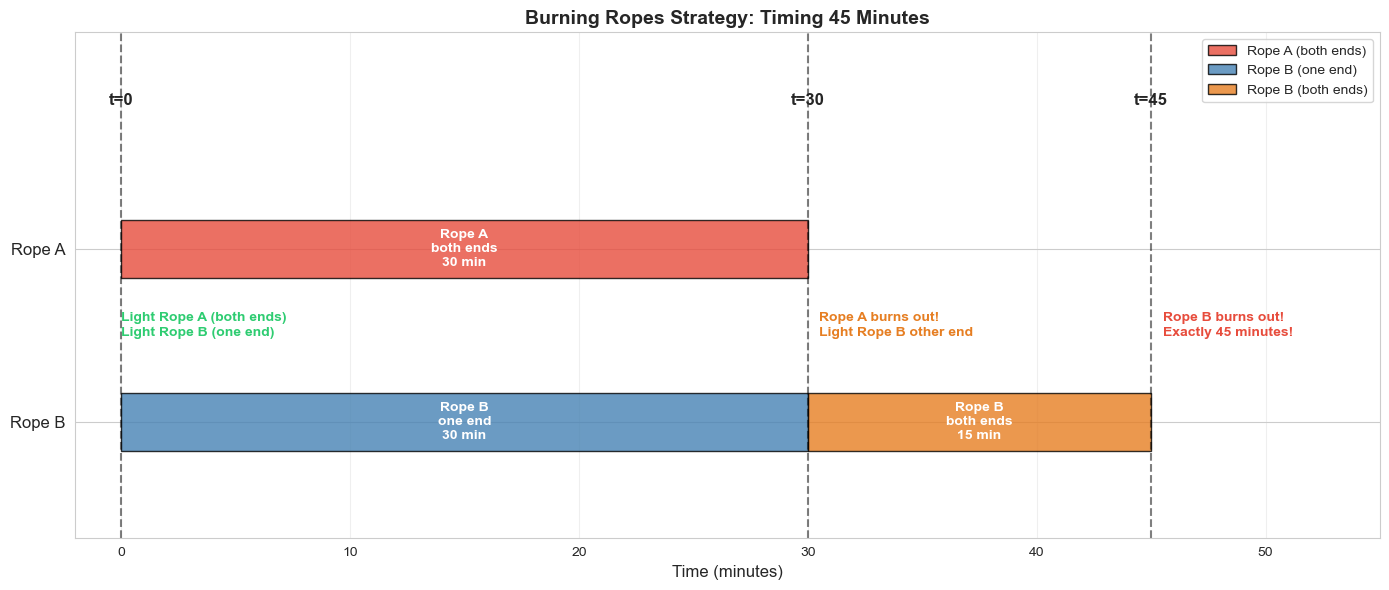


💡 图解说明：
  红色条: 绳子A两端同时烧, 0-30分钟
  蓝色条: 绳子B单端烧, 0-30分钟
  橙色条: 绳子B双端烧 (30分钟时点燃另一端), 30-45分钟
  总计: 30 + 15 = 45 分钟 ✅


In [15]:
# ========== 步骤 4: 可视化 - 烧绳时间线 ==========
fig, ax = plt.subplots(figsize=(14, 6))

# 时间线
y_rope_a = 2.0
y_rope_b = 0.8

# 绳子A: 0-30分钟 (双端)
ax.barh(y_rope_a, 30, left=0, height=0.4, color='#e74c3c', 
        edgecolor='black', alpha=0.8, label='Rope A (both ends)')
ax.text(15, y_rope_a, 'Rope A\nboth ends\n30 min', ha='center', va='center',
        fontweight='bold', fontsize=10, color='white')

# 绳子B: 0-30分钟 (单端)
ax.barh(y_rope_b, 30, left=0, height=0.4, color='steelblue',
        edgecolor='black', alpha=0.8, label='Rope B (one end)')
ax.text(15, y_rope_b, 'Rope B\none end\n30 min', ha='center', va='center',
        fontweight='bold', fontsize=10, color='white')

# 绳子B: 30-45分钟 (双端)
ax.barh(y_rope_b, 15, left=30, height=0.4, color='#e67e22',
        edgecolor='black', alpha=0.8, label='Rope B (both ends)')
ax.text(37.5, y_rope_b, 'Rope B\nboth ends\n15 min', ha='center', va='center',
        fontweight='bold', fontsize=10, color='white')

# 时间标记
for t, label in [(0, 't=0'), (30, 't=30'), (45, 't=45')]:
    ax.axvline(x=t, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
    ax.text(t, 3.0, label, ha='center', fontsize=12, fontweight='bold')

# 事件标注
ax.annotate('Light Rope A (both ends)\nLight Rope B (one end)',
           xy=(0, 1.4), fontsize=10, color='#2ecc71', fontweight='bold')
ax.annotate('Rope A burns out!\nLight Rope B other end',
           xy=(30.5, 1.4), fontsize=10, color='#e67e22', fontweight='bold')
ax.annotate('Rope B burns out!\nExactly 45 minutes!',
           xy=(45.5, 1.4), fontsize=10, color='#e74c3c', fontweight='bold')

ax.set_xlabel('Time (minutes)', fontsize=12)
ax.set_xlim(-2, 55)
ax.set_ylim(0, 3.5)
ax.set_yticks([y_rope_b, y_rope_a])
ax.set_yticklabels(['Rope B', 'Rope A'], fontsize=12)
ax.set_title('Burning Ropes Strategy: Timing 45 Minutes', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n💡 图解说明：")
print(f"  红色条: 绳子A两端同时烧, 0-30分钟")
print(f"  蓝色条: 绳子B单端烧, 0-30分钟")
print(f"  橙色条: 绳子B双端烧 (30分钟时点燃另一端), 30-45分钟")
print(f"  总计: 30 + 15 = 45 分钟 ✅")

In [16]:
# ========== 步骤 5: 拓展 - 能计时哪些时间? ==========
print("📊 步骤 5: 两根绳子能计时哪些时间?")
print("=" * 50)
print()
print("  一根绳子的能力:")
print("    - 单端: 60 分钟")
print("    - 双端: 30 分钟")
print()
print("  两根绳子的组合策略:")
print()

timings = [
    ("60", "A单端", "不用B"),
    ("30", "A双端", "不用B"),
    ("90", "A单端 → B单端", "串行"),
    ("120", "A单端 → B单端", "(等价于2根串行)"),
    ("45", "A双端 + B单端 → B双端", "如上所述"),
    ("15", "A双端 + B双端, A完后看B", "同时双端烧两根"),
]

print(f"  {'时间':>6} │ {'策略':>30} │ 说明")
print(f"  {'─'*6}─┼─{'─'*30}─┼─{'─'*20}")
for t, strat, note in timings:
    print(f"  {t:>4}分钟 │ {strat:>30} │ {note}")

print(f"\n💡 通过不同的点燃时机组合, 两根不均匀绳子可以计时多种时间")
print(f"   核心技巧: '双端烧 = 时间减半' 是密度无关的!")

📊 步骤 5: 两根绳子能计时哪些时间?

  一根绳子的能力:
    - 单端: 60 分钟
    - 双端: 30 分钟

  两根绳子的组合策略:

      时间 │                             策略 │ 说明
  ───────┼────────────────────────────────┼─────────────────────
    60分钟 │                            A单端 │ 不用B
    30分钟 │                            A双端 │ 不用B
    90分钟 │                      A单端 → B单端 │ 串行
   120分钟 │                      A单端 → B单端 │ (等价于2根串行)
    45分钟 │                A双端 + B单端 → B双端 │ 如上所述
    15分钟 │               A双端 + B双端, A完后看B │ 同时双端烧两根

💡 通过不同的点燃时机组合, 两根不均匀绳子可以计时多种时间
   核心技巧: '双端烧 = 时间减半' 是密度无关的!


---

## 5. 方法论总结：问题简化的通用框架

### 🎯 三步框架

```
步骤 1: 缩小规模
  ┌──────────────────────────────────────────────┐
  │  原问题: N=100, 太复杂                        │
  │  简化到: N=1, 2, 3... 可以手算                │
  └──────────────────────────────────────────────┘
                    ↓
步骤 2: 发现规律
  ┌──────────────────────────────────────────────┐
  │  列出小规模的解: f(1), f(2), f(3), ...        │
  │  寻找递推关系: f(N) 如何依赖 f(N-1)?          │
  │  或寻找直接公式: f(N) = ...                   │
  └──────────────────────────────────────────────┘
                    ↓
步骤 3: 推广验证
  ┌──────────────────────────────────────────────┐
  │  用归纳法证明递推关系                          │
  │  代入 N=100 得到答案                           │
  │  用 Python 暴力/模拟验证                       │
  └──────────────────────────────────────────────┘
```

### 📝 三个谜题的对比

| 维度 | 海盗分金 | 老虎吃羊 | 烧绳计时 |
|------|----------|----------|----------|
| 简化方式 | N=5 → N=2 | N=100 → N=1 | 复合问题 → 单绳分析 |
| 递推方向 | 逆向 (从末尾往前) | 正向 (从基础情况) | 分解子问题 |
| 核心规律 | 收买备选最差的海盗 | 奇偶交替 | 双端 = 时间减半 |
| 验证方式 | 穷举收买组合 | 递推函数 | 模拟不均匀绳子 |
| 思维方式 | 博弈论 (纳什均衡) | 数学归纳法 | 物理约束分析 |

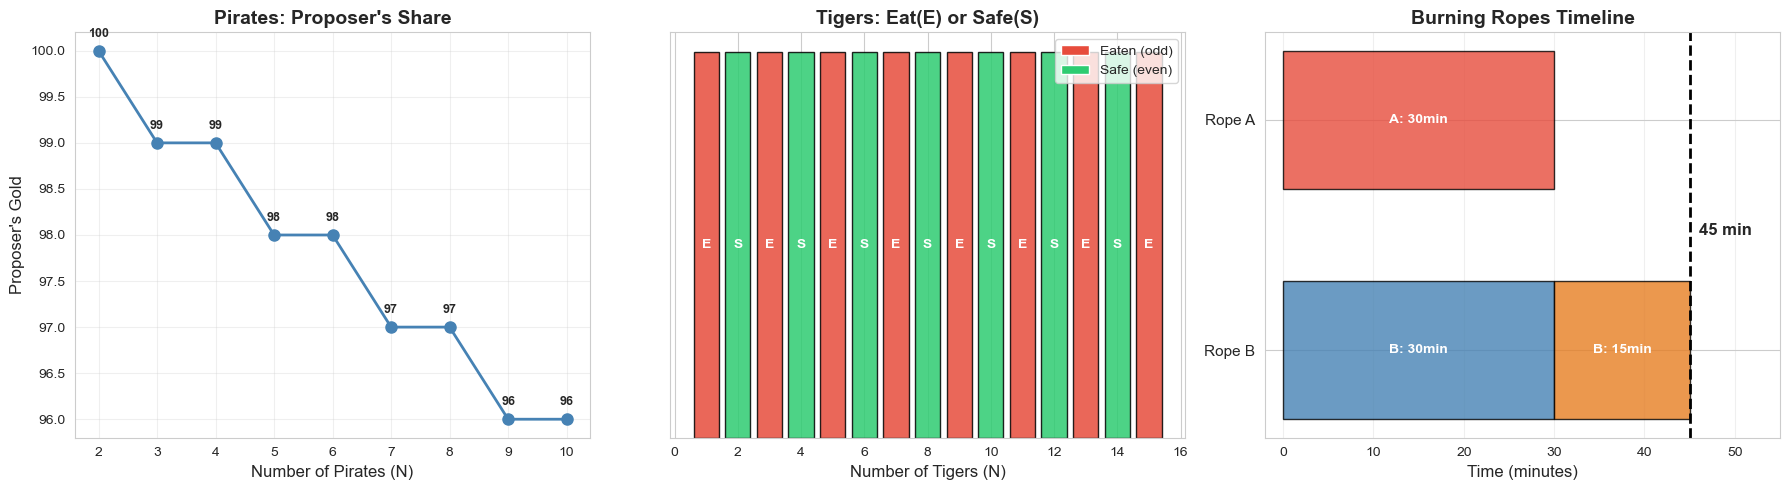


💡 图解说明：
  三个谜题都使用了 '问题简化' 策略:
  左图: 海盗分金 - 从 N=2 递推到 N=10
  中图: 老虎吃羊 - 从 N=1 发现奇偶规律
  右图: 烧绳计时 - 分解为 30+15 两个子问题


In [17]:
# ========== 综合可视化: 三个谜题的简化过程 ==========
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 谜题1: 海盗分金 - 提案者收益随N ==========
ax1 = axes[0]
ns = list(range(2, 11))
proposer = [solve_pirates(n)[n-1] for n in ns]
ax1.plot(ns, proposer, 'o-', color='steelblue', linewidth=2, markersize=8)
for n, p in zip(ns, proposer):
    ax1.annotate(f'{p}', (n, p), textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=9, fontweight='bold')
ax1.set_xlabel('Number of Pirates (N)', fontsize=12)
ax1.set_ylabel('Proposer\'s Gold', fontsize=12)
ax1.set_title('Pirates: Proposer\'s Share', fontsize=14, fontweight='bold')
ax1.grid(alpha=0.3)

# --- 谜题2: 老虎吃羊 - 奇偶 ==========
ax2 = axes[1]
ns2 = list(range(1, 16))
eaten2 = [1 if tiger_sheep(n) else 0 for n in ns2]
colors2 = ['#e74c3c' if e else '#2ecc71' for e in eaten2]
ax2.bar(ns2, [1]*len(ns2), color=colors2, edgecolor='black', alpha=0.85)
for n, e in zip(ns2, eaten2):
    ax2.text(n, 0.5, 'E' if e else 'S', ha='center', va='center',
            fontweight='bold', color='white', fontsize=10)
ax2.set_xlabel('Number of Tigers (N)', fontsize=12)
ax2.set_yticks([])
ax2.set_title('Tigers: Eat(E) or Safe(S)', fontsize=14, fontweight='bold')
legend_elements = [Patch(facecolor='#e74c3c', label='Eaten (odd)'),
                   Patch(facecolor='#2ecc71', label='Safe (even)')]
ax2.legend(handles=legend_elements, fontsize=10)

# --- 谜题3: 烧绳 - 时间线 ==========
ax3 = axes[2]
# 简化的甘特图
ax3.barh(1.5, 30, left=0, height=0.6, color='#e74c3c', edgecolor='black', alpha=0.8)
ax3.text(15, 1.5, 'A: 30min', ha='center', va='center', fontweight='bold',
        color='white', fontsize=10)

ax3.barh(0.5, 30, left=0, height=0.6, color='steelblue', edgecolor='black', alpha=0.8)
ax3.text(15, 0.5, 'B: 30min', ha='center', va='center', fontweight='bold',
        color='white', fontsize=10)

ax3.barh(0.5, 15, left=30, height=0.6, color='#e67e22', edgecolor='black', alpha=0.8)
ax3.text(37.5, 0.5, 'B: 15min', ha='center', va='center', fontweight='bold',
        color='white', fontsize=10)

ax3.axvline(x=45, color='black', linewidth=2, linestyle='--')
ax3.text(46, 1.0, '45 min', fontsize=12, fontweight='bold')

ax3.set_xlabel('Time (minutes)', fontsize=12)
ax3.set_yticks([0.5, 1.5])
ax3.set_yticklabels(['Rope B', 'Rope A'], fontsize=11)
ax3.set_title('Burning Ropes Timeline', fontsize=14, fontweight='bold')
ax3.set_xlim(-2, 55)
ax3.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n💡 图解说明：")
print(f"  三个谜题都使用了 '问题简化' 策略:")
print(f"  左图: 海盗分金 - 从 N=2 递推到 N=10")
print(f"  中图: 老虎吃羊 - 从 N=1 发现奇偶规律")
print(f"  右图: 烧绳计时 - 分解为 30+15 两个子问题")

---

## 6. 核心概念回顾

### 📌 问题简化 (Problem Simplification)
- **定义**: 将复杂的大规模问题缩小到最简单的情形，手算求解后逐步推广
- **适用条件**: 问题具有递推结构（大问题的解依赖于小问题的解）
- **关键步骤**: 确定基础情况 → 建立递推关系 → 归纳推广

### 📌 逆向递推 (Backward Induction)
- **定义**: 从博弈的最后阶段开始分析，逆向推导每个参与者的最优决策
- **应用**: 海盗分金——从 2 人博弈推到 5 人博弈
- **含义**: 理性参与者会预见未来所有可能的情景，据此做出当前最优选择

### 📌 奇偶分析 (Parity Analysis)
- **定义**: 通过分析问题的奇偶性质，将无穷递推简化为简单规律
- **应用**: 老虎吃羊——奇数吃、偶数不吃
- **公式**: $f(N) = \lnot f(N-1)$（取反递推）

### 📌 子问题分解 (Subproblem Decomposition)
- **定义**: 将一个复杂目标拆解为多个可独立求解的子问题
- **应用**: 烧绳计时——45 分钟 = 30 分钟 + 15 分钟
- **关键**: 识别子问题之间的依赖关系和并行操作的可能性

### 🔗 完整流程
```
面对复杂问题 → 缩小规模 → 手算小实例 → 发现规律
      ↓              ↓           ↓            ↓
  N太大无从下手   N=1,2,3    列出解序列    递推/公式
                                              ↓
                              推广到原始N → Python验证
```

### 📝 方法选择指南

| 问题特征 | 推荐方法 | 示例 |
|----------|----------|------|
| 多人博弈，依次决策 | 逆向递推 | 海盗分金 |
| 递推关系简单 | 奇偶/周期分析 | 老虎吃羊 |
| 目标可拆分 | 子问题分解 | 烧绳计时 |
| 状态空间有限 | BFS/DFS 穷举 | 过河问题 |
| 连续参数 | 参数扫描 + 可视化 | 概率优化 |

---

## 7. 常见误区

### ❌ 误区 1: 简化后的小问题答案可以直接等比放大到原问题
**✓ 正确理解**: 简化是为了**发现递推规律**，而非简单地缩放答案。海盗分金中 N=3 的答案 (99,1,0) 不能通过乘以某个系数得到 N=5 的答案。必须逐步递推，每一步都要重新分析参与者的最优策略。

### ❌ 误区 2: 老虎吃羊问题中，100 只老虎比 1 只老虎更危险
**✓ 正确理解**: 恰恰相反！100 只老虎（偶数）时羊是安全的，而 1 只老虎（奇数）时羊会被吃。数量多不代表危险——**奇偶性**才是关键。这个反直觉的结论正是递推分析的价值所在。

### ❌ 误区 3: 烧绳问题中，绳子烧到一半长度 = 过了 30 分钟
**✓ 正确理解**: 绳子密度不均匀，长度与时间**不成正比**。可能前 1/4 长度花了 50 分钟，后 3/4 只花 10 分钟。唯一确定的是：**整根烧完 = 60 分钟**，**双端烧完 = 30 分钟**。

### ❌ 误区 4: 问题简化只适用于离散/整数问题
**✓ 正确理解**: 问题简化同样适用于连续问题。例如，在求解复杂积分或概率时，可以先考虑 N=2 的简化版本，找到递推公式后再推广。烧绳问题就是一个连续参数（时间）的例子。

### ❌ 误区 5: 在海盗分金中，提案者应该给每个人一些金币以获得更多支持
**✓ 正确理解**: 最优策略是**只收买刚好足够的人数**，并且收买**成本最低**的海盗。给多余的人分金币只会减少自己的收益，不会增加安全性。理性博弈中，精确计算比"撒钱买好"更有效。